In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import joblib

In [6]:
from google.colab import files

uploaded = files.upload()

Saving final_test_processed.csv to final_test_processed (1).csv
Saving final_train_processed.csv to final_train_processed (1).csv


In [7]:
import pandas as pd

df = pd.read_csv("final_train_processed.csv")
df = pd.read_csv("final_test_processed.csv")

print(df.shape)
df.head()

(1914, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.196483,0,0.193211,1.394672,-1.341260,0.878882,0,0,0.615301,0,0,-0.034391,0.961455,-1.195658,-0.458065,0,1,0
1,1.130834,1,-1.182269,0.011320,0.353342,0.878882,0,1,-0.244237,1,0,-0.028813,0.474536,-0.288717,-0.063557,0,0,0
2,0.637989,0,-1.182269,0.702996,1.066331,-0.772148,1,1,-0.268687,1,0,-0.026335,1.276520,1.381400,-0.679976,1,0,0
3,0.196483,1,-1.605493,-1.372033,1.240514,-0.772148,0,0,-1.094971,0,0,-0.014848,-1.065275,1.567844,0.429578,0,0,1
4,-0.265559,0,-0.441626,-1.717871,-1.341260,0.878882,1,0,0.196402,0,1,-0.034391,-1.530426,-1.195658,4.867794,0,1,0


In [8]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1914, 17)
y shape: (1914,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1531, 17)
Testing data: (383, 17)


In [10]:
ann_model = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
input_shape=(X_train.shape[1],)

In [12]:
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [15]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7966 - loss: 0.5176 - val_accuracy: 0.7818 - val_loss: 0.5016
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8080 - loss: 0.4629 - val_accuracy: 0.7818 - val_loss: 0.4794
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8080 - loss: 0.4466 - val_accuracy: 0.7850 - val_loss: 0.4624
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8080 - loss: 0.4297 - val_accuracy: 0.7785 - val_loss: 0.4557
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8162 - loss: 0.4244 - val_accuracy: 0.7850 - val_loss: 0.4494
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8088 - loss: 0.4123 - val_accuracy: 0.7883 - val_loss: 0.4432
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8186 - loss: 0.4192 - val_accuracy: 0.8013 - val_loss: 0.4410
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8170 - loss: 0.4179 - val_accuracy: 0.7948 - 

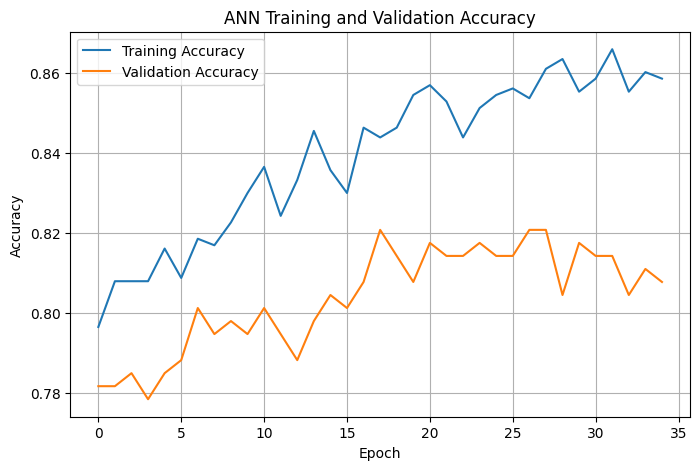

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

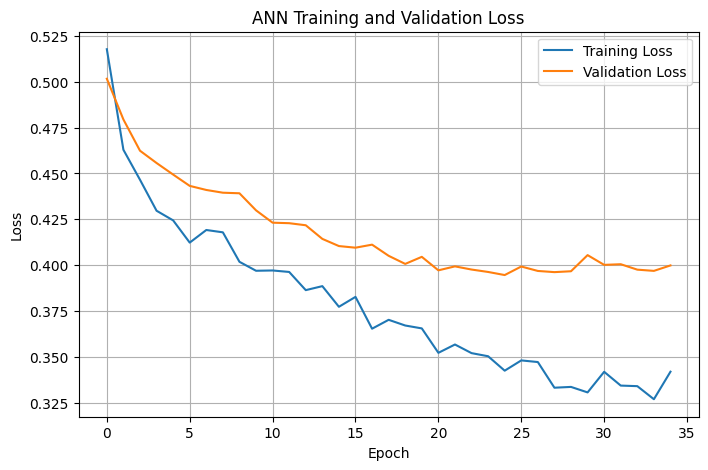

In [17]:
#loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [19]:
# Get prediction probabilities
y_pred_proba = ann_model.predict(
    X_test,
    verbose=0
).ravel()

print(y_pred_proba[:10])

[0.00631524 0.0730213  0.893899   0.01567584 0.06709205 0.01445629
 0.07513037 0.24607304 0.02060474 0.12639745]


In [20]:
# Convert probabilities to class predictions
y_pred = (y_pred_proba >= 0.5).astype(int)

print(y_pred[:10])

[0 0 1 0 0 0 0 0 0 0]


In [21]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print("ANN Results")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

ANN Results
-------------------------
Accuracy : 0.8668
Precision: 0.7451
Recall   : 0.5000
F1 Score : 0.5984
ROC-AUC  : 0.8817


In [22]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       307
           1       0.75      0.50      0.60        76

    accuracy                           0.87       383
   macro avg       0.82      0.73      0.76       383
weighted avg       0.86      0.87      0.86       383



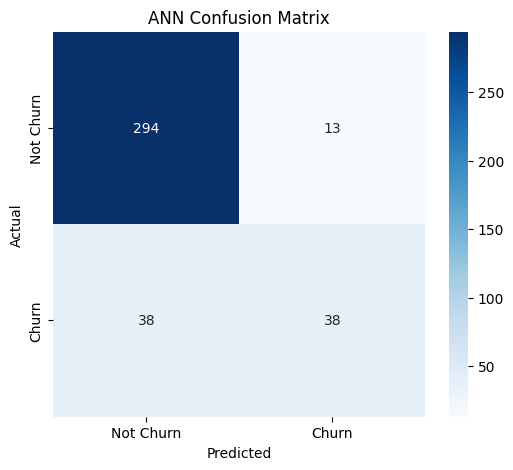

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

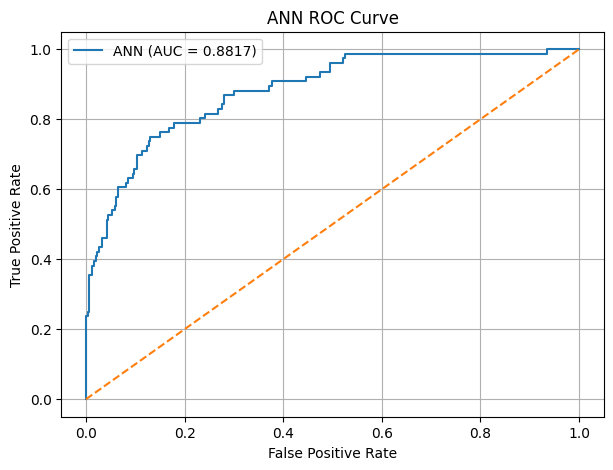

In [24]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ANN ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [25]:
ann_model.save(
    "ann_model.keras"
)

print("ANN model saved successfully!")

ANN model saved successfully!


In [26]:
ann_results = pd.DataFrame({
    "Model": ["ANN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

ann_results.to_csv(
    "ann_results.csv",
    index=False
)

print(ann_results)

  Model  Accuracy  Precision  Recall  F1_Score   ROC_AUC
0   ANN  0.866841   0.745098     0.5  0.598425  0.881665


In [27]:
ann_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_pred_proba
})

ann_predictions.to_csv(
    "ann_predictions.csv",
    index=False
)

print("ANN predictions saved successfully!")

ANN predictions saved successfully!


In [28]:
ann_results = pd.read_csv("ann_results.csv")